## Private Finance RAG with RAGWire and Ollama

#### Production-grade RAG toolkit for document ingestion and retrieval with hybrid search support.

- RAGWire handles the full RAG pipeline — from loading raw documents to storing and retrieving them from a vector database- so you can focus on building your application.

- Tech Requirements
    - Ollama
    - Qdrant VectorDB
    

In [1]:
from ragwire import RAGWire

rag = RAGWire("config.yaml")

# Ingest
stats = rag.ingest_documents(["data/Apple_10k_2025.pdf"])
print(f"Chunks created: {stats['chunks_created']}")

c:\Users\laxmi\anaconda3\envs\ml\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(
c:\Users\laxmi\anaconda3\envs\ml\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)
Ingesting: 100%|██████████| 1/1 [01:02<00:00, 62.96s/file]


Chunks created: 35


In [2]:
# Retrieve
results = rag.retrieve("What is Apple's total revenue?", top_k=5)

In [3]:
results

[Document(metadata={'source': 'data/Apple_10k_2025.pdf', 'file_name': 'Apple_10k_2025.pdf', 'file_type': 'pdf', 'file_hash': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab', 'chunk_id': '108590052c3ba5400c63660d787fe7ed4e43868292946d7a7facebe9ab7d1aab_16', 'chunk_hash': '60b8d552baec48866282206f62d1d54dad52bc158891d1dcf5f9849c24cf4082', 'chunk_index': 16, 'total_chunks': 35, 'created_at': '2026-03-24T05:19:06.871615+00:00', 'company_name': 'apple inc', 'doc_type': '10-k', 'fiscal_quarter': None, 'fiscal_year': [2025], '_id': 'a6e24656-e599-4ddb-87e6-84a8a231e093', '_collection_name': 'my_docs_youtube'}, page_content='Earnings per share:\n\nBasic\nDiluted\n\nShares used in computing earnings per share:\n\nBasic\n\nDiluted\n\nSeptember 27,\n2025\n\nYears ended\n\nSeptember 28,\n2024\n\nSeptember 30,\n2023\n\n$\n\n$\n\n$\n$\n\n307,003  $\n109,158\n\n416,161\n\n294,866  $\n96,169\n\n391,035\n\n194,116\n26,844\n\n220,960\n\n195,201\n\n34,550\n27,601\n62,151\n\n185,233\n25

### RAG Agent End to End

In [4]:
from langchain.agents import create_agent
from langchain.tools import tool
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver
from ragwire import RAGWire

rag = RAGWire("config.yaml")
rag.ingest_directory("data/")

@tool
def search_documents(query: str) -> str:
    """Search the document knowledge base for relevant information."""
    results = rag.retrieve(query, top_k=5)
    if not results:
        return "No relevant documents found."
    return "\n\n---\n\n".join(
        f"[{doc.metadata.get('file_name')}]\n{doc.page_content}"
        for doc in results
    )

agent = create_agent(
    model=ChatOllama(model="qwen3.5:9b"),
    tools=[search_documents],
    system_prompt="You are a helpful document assistant. Use search_documents to answer questions.",
    checkpointer=InMemorySaver(),
)



Ingesting: 100%|██████████| 1/1 [00:00<00:00, 147.87file/s]


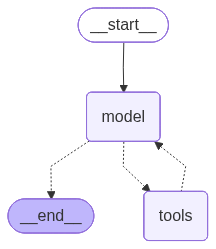

In [5]:
agent

In [6]:
from langchain.messages import HumanMessage
config = {"configurable": {"thread_id": "session-1"}}
response = agent.invoke(
    {"messages": [HumanMessage("What is the total revenue?")]},
    config=config,
)

In [7]:
response

{'messages': [HumanMessage(content='What is the total revenue?', additional_kwargs={}, response_metadata={}, id='c6c6a764-a73e-4180-9dba-2b961abaadfb'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3.5:9b', 'created_at': '2026-03-24T05:24:54.5358427Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7799680400, 'load_duration': 6108830400, 'prompt_eval_count': 291, 'prompt_eval_duration': 224352700, 'eval_count': 79, 'eval_duration': 1387012200, 'logprobs': None, 'model_name': 'qwen3.5:9b', 'model_provider': 'ollama'}, id='lc_run--019d1e4d-780f-7fc2-95a3-6e6e8ac2d7b3-0', tool_calls=[{'name': 'search_documents', 'args': {'query': 'total revenue'}, 'id': 'f69884df-83ff-43cd-95a3-75b706ec65e1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 291, 'output_tokens': 79, 'total_tokens': 370}),
  ToolMessage(content='[Apple_10k_2025.pdf]\nEarnings per share:\n\nBasic\nDiluted\n\nShares used in computing earnings per share:\

In [8]:
print(response["messages"][-1].content)

Based on the financial documents, Apple's **total revenue (net sales)** for the most recent fiscal year ended September 27, 2025 was **$416.16 billion** ($416,161 million).

Here are the revenue figures for the last three fiscal years:
- **2025 (ended Sept 27, 2025)**: $416.16 billion
- **2024 (ended Sept 28, 2024)**: $391.04 billion
- **2023 (ended Sept 30, 2023)**: $383.29 billion

The revenue breakdown by product category for 2025:
- **iPhone**: $209.59 billion
- **Services**: $109.16 billion
- **Mac**: $33.71 billion
- **iPad**: $28.02 billion
- **Wearables, Home and Accessories**: $35.69 billion
